# 03 — Moving Average (Baseline)

Implements a simple Moving Average model as the performance baseline.
For each point in the test set, the prediction is the mean of the last `n` closing prices.

**Input:** `data/processed/<TICKER>_train.csv` and `data/processed/<TICKER>_test.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Parameters

In [2]:
TICKER  = 'AAPL'
WINDOW  = 30    # number of past days used to compute the average

## Load Data

In [3]:
train = pd.read_csv(f'../data/processed/{TICKER}_train.csv', index_col='Date', parse_dates=True)
test  = pd.read_csv(f'../data/processed/{TICKER}_test.csv',  index_col='Date', parse_dates=True)

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 1205 rows | Test: 302 rows


## Predict

For each step in the test set, the prediction is the mean of the last `WINDOW` prices.
We use a rolling window over the full series (train + test) to simulate real forecasting conditions.

In [4]:
# Combine train and test to compute rolling mean across the boundary
full = pd.concat([train, test])
rolling = full['Close'].rolling(window=WINDOW).mean()

# Predictions are the rolling mean shifted by 1 (predict next day using last WINDOW days)
predictions = rolling.shift(1).loc[test.index]
actuals     = test['Close']

print(f"Predictions: {len(predictions)} | NaNs: {predictions.isnull().sum()}")

Predictions: 302 | NaNs: 0


In [5]:
# Visual check: compare actual vs prediction for the first 10 test days
comparison = pd.DataFrame({
    'Actual':     actuals,
    'Predicted':  predictions,
    'Error':      actuals - predictions
})
comparison.head(10)

,Actual,Predicted,Error
Date,,,
2024-10-16,230.267380,223.749874,6.517505
2024-10-17,230.634979,224.111830,6.523149
2024-10-18,233.466370,224.435371,9.030999
2024-10-21,234.936691,224.904952,10.031739
2024-10-22,234.320770,225.420564,8.900206
2024-10-23,229.254044,225.942138,3.311905
2024-10-24,229.065308,226.210376,2.854932
2024-10-25,229.899811,226.468679,3.431131
2024-10-28,231.876816,226.763741,5.113075


## Metrics

In [6]:
mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

MAE:  9.3326
RMSE: 11.6511
MAPE: 4.0706%


## Plot — Actual vs Predicted

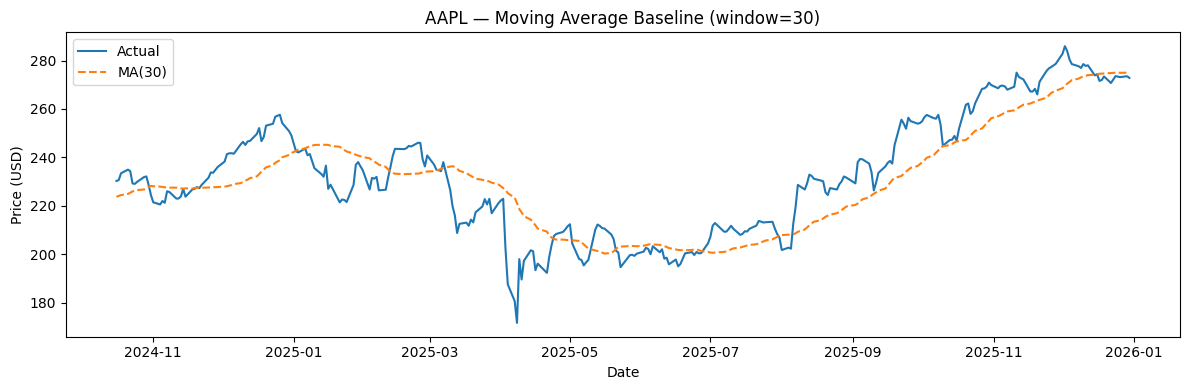

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actuals.index, actuals,     label='Actual')
ax.plot(actuals.index, predictions, label=f'MA({WINDOW})', linestyle='--')
ax.set_title(f'{TICKER} — Moving Average Baseline (window={WINDOW})')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## Save Results

Save predictions to `data/results/` so the model comparison notebook can load them.


In [8]:
import os
os.makedirs('../data/results', exist_ok=True)

results = pd.DataFrame({
    'Actual':    actuals.values,
    'Predicted': predictions.values,
}, index=actuals.index)

results.to_csv(f'../data/results/moving_average_{TICKER}.csv')
print(f"Saved to data/results/moving_average_{TICKER}.csv")


Saved to data/results/moving_average_AAPL.csv
